# Assigment 2
Noah Tingratt 2005-07-20-3057

I have used for this assigment chatgpt to understand hog in combination with the other avalible package and dokumentation of different package. The prigional and required assigment. The total time of this assigment is very much especially the second part. Everything will be very summerized. No longer code is generated by chatgpt or something else. Google defaults coding asssistant in colab have been used.

In [ ]:
!pip install numpy scipy statsmodels matplotlib tensorflow scikit-image scikit-learn tqdm

Install package and data set below

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import mnist, cifar10

from tensorflow.keras import layers, models

In [ ]:
(mnist_train_x, mnist_train_ground_truth), (mnist_test_x, mnist_test_ground_truth) = mnist.load_data()

(cifar10_train_x, cifar10_train_ground_truth), (cifar10_test_x, cifar10_test_ground_truth) = cifar10.load_data()



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Normilize the data set below with min max and with std=1 and mean 1 for cifar

In [ ]:

mnist_train_x = mnist_train_x.astype("float")
mnist_test_x = mnist_test_x.astype("float")

mnist_train_x_normilized = mnist_train_x/255. #vet fel först påverkar ej
mnist_test_x_normilized = mnist_test_x/255. #vet fel förat påverkar ej

cifar10_train_x = cifar10_train_x.astype("float")
cifar10_test_x = cifar10_test_x.astype("float")

mean_cifar10_train_x = np.mean(cifar10_train_x)
std_cifar10_train_x = np.std(cifar10_train_x)

cifar10_train_x_normilized = (cifar10_train_x - mean_cifar10_train_x) / std_cifar10_train_x
cifar10_test_x_normilized = (cifar10_test_x - mean_cifar10_train_x) / std_cifar10_train_x

print("mnist shape: ", mnist_train_x.shape)
print("cifar10 shape: ", cifar10_train_x.shape)

print(np.max(mnist_train_ground_truth))
print(np.min(mnist_train_ground_truth))
print(np.max(cifar10_train_ground_truth))
print(np.min(cifar10_train_ground_truth))

mnist shape:  (60000, 28, 28)
cifar10 shape:  (50000, 32, 32, 3)
9
0
9
0


In [ ]:
class_names_cifar10 = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] #copied from tensorflow documentation


Make a small Cnn network for mnist about same accurrucy if size small because the sytem will still learn with does setting everything adam "inzooming" was used as a optimizerr

In [ ]:

mnist_model = models.Sequential()
filters_layer_1 = 32
filter_size = (3, 3)
pool_size = (2, 2)
filters_layer_3 = 32
neurons_layer_5 = 128
drop_out_rate_layer_5 = 0.3
out_put_size = 10

#layer 1
mnist_model.add(layers.Conv2D(filters_layer_1, filter_size))
mnist_model.add(layers.BatchNormalization())
mnist_model.add(layers.Activation('relu'))

#layer 2
mnist_model.add(layers.MaxPool2D(pool_size = pool_size))

# layer 3
mnist_model.add(layers.Conv2D(filters_layer_1, filter_size))
mnist_model.add(layers.BatchNormalization())
mnist_model.add(layers.Activation('relu'))

#layer 4
mnist_model.add(layers.MaxPool2D(pool_size = pool_size))

# flatten to
mnist_model.add(layers.Flatten())

# layer 5
mnist_model.add(layers.Dense(neurons_layer_5, activation = "relu"))
mnist_model.add(layers.Dropout(drop_out_rate_layer_5))

# layer 6
mnist_model.add(layers.Dense(out_put_size, activation = "softmax"))

#CNN network
mnist_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")


functions to get train and test accurucy for mnist and cifar10 and optimize and evaluate the function (CNN) on test set (no validation set used here because we dont use test set to optimize only se result and not stoppage of epoch). Validation set is commonly neassasary but I dont use a holdout validation here or compare models more than directly on test set. I wanted with mnist lowest complexity of arcictecture and therefore that structure.

In [ ]:
def get_train_accuracy(local_model, name_of_data_set="mnist", verbose=1):
  if name_of_data_set == "mnist":
    train_x_normilized = mnist_train_x_normilized[:, :, :, np.newaxis]
    train_ground_truth = mnist_train_ground_truth
  elif name_of_data_set == "cifar10":
    train_x_normilized = cifar10_train_x_normilized
    train_ground_truth = cifar10_train_ground_truth

  train_prediction = local_model.predict(train_x_normilized, verbose=verbose).argmax(axis=1)
  accurucy_train = np.mean(np.array([train_prediction[i] == train_ground_truth[i] for i in range(train_ground_truth.size)]))
  return accurucy_train

def get_test_accuracy(local_model, name_of_data_set="mnist", verbose = 1):
  if name_of_data_set == "mnist":
    test_x_normilized = mnist_test_x_normilized[:, :, :, np.newaxis]
    test_ground_truth = mnist_test_ground_truth
  elif name_of_data_set == "cifar10":
    test_x_normilized = cifar10_test_x_normilized
    test_ground_truth = cifar10_test_ground_truth

  test_prediction = local_model.predict(test_x_normilized, verbose=verbose).argmax(axis=1)
  accurucy_test = np.mean(np.array([test_prediction[i] == test_ground_truth[i] for i in range(test_ground_truth.size)]))
  return accurucy_test

def fit_model(local_model, epoches=1, name_of_data_set="mnist", batch_size=32, calculate_training_accuracy=True, calculate_test_accuracy=True, learning_rate = 0.001):
  if name_of_data_set == "mnist":
    train_x_normilized = mnist_train_x_normilized[:, :, :, np.newaxis]
    train_ground_truth = mnist_train_ground_truth

  elif name_of_data_set == "cifar10":
    train_x_normilized = cifar10_train_x_normilized
    train_ground_truth = cifar10_train_ground_truth

  local_model.optimizer.learning_rate.assign(learning_rate)

  local_model.fit(train_x_normilized, train_ground_truth, epochs=epoches, verbose=1, batch_size=batch_size)

  accurucy_train, accurucy_test = None, None

  if calculate_training_accuracy:
    accurucy_train = get_train_accuracy(local_model, name_of_data_set, verbose=0)
    print("accurucy_train:", accurucy_train)

  if calculate_test_accuracy:
    accurucy_test = get_test_accuracy(local_model, name_of_data_set, verbose=0)
    print("accurucy_test:", accurucy_test )

  return accurucy_train, accurucy_test


In [ ]:
mnist_accurucy_train, mnist_accurucy_test = fit_model(mnist_model, 20, "mnist")


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3456
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0721
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0506
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0443
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0373
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0303
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0264
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0228
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0191
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0176
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0149
Epoch 12/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0127
Epoch 13/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0143
Epoch 14/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0103
Epoch 15/20
1875/1875 ━━━━━━

After 10 epochs

Training Accurucy ≃ 99.6467 %

Test Accurucy = 99.04 %



After 20 epochs

Training Accurucy ≃ 99.95%

Test Accurucy = 99.27 %


Generates below a cnn network by list as inputs

In [ ]:
def get_model_c(filters_in_layer = None, sizes_of_filters_in_layers=None, number_of_hidden_neurons_in_layers = None, max_pool_in_layers = None, dropouts_in_layers = None, drop_out_rate_fnn = 0.3, drop_out_rate_cnn = 0.3):
  Cifar10_Model = models.Sequential()
  filters_in_layer = np.array([32, 32]) if filters_in_layer is None else filters_in_layer
  filter_sizes = [(3, 3) for i in range(filters_in_layer.shape[0])] if sizes_of_filters_in_layers is None else [(size_of_filter, size_of_filter) for size_of_filter in sizes_of_filters_in_layers]
  pool_size = (2, 2)
  number_of_hidden_neurons_in_layers = np.array([128]) if number_of_hidden_neurons_in_layers is None else number_of_hidden_neurons_in_layers
  dropouts_in_layers = np.array([False for i in range(filters_in_layer.shape[0])]) if dropouts_in_layers is None else dropouts_in_layers
  max_pool_in_layers = np.array([False for i in range(filters_in_layer.shape[0])]) if dropouts_in_layers is None else dropouts_in_layers

  out_put_size = 10

  #CNN layers
  for layer in range(filters_in_layer.shape[0]):
    Cifar10_Model.add(layers.Conv2D(filters_in_layer[layer], filter_sizes[layer], padding="same"))

    Cifar10_Model.add(layers.BatchNormalization())
    Cifar10_Model.add(layers.Activation('relu'))

    if max_pool_in_layers[layer]:
      Cifar10_Model.add(layers.MaxPool2D(pool_size = pool_size, padding="same"))
    if max_pool_in_layers[layer]:
      Cifar10_Model.add(layers.Dropout(drop_out_rate_cnn))

  #layer 2

  # flatten to
  Cifar10_Model.add(layers.Flatten())

  # layer 5
  for layer in range(number_of_hidden_neurons_in_layers.size):
    Cifar10_Model.add(layers.Dense(number_of_hidden_neurons_in_layers[layer], activation = "relu"))
    Cifar10_Model.add(layers.Dropout(drop_out_rate_fnn))

  # layer 6
  Cifar10_Model.add(layers.Dense(out_put_size, activation = "softmax"))

  #CNN network
  Cifar10_Model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")
  return Cifar10_Model

functios of four different functions.

In [ ]:
def get_model_1():
  model_name = "model 1"
  model_describtion = "increasing number of filters alterning dropouts & max pool in layers. Batchnorm and relu used, higher dropout in ffnn than cnn"
  number_of_filters_in_layers = np.array([32, 32, 64, 64, 128, 128])
  sizes_of_filters_in_layers = np.array([3, 3, 3, 3, 3, 3])
  number_of_hidden_neurons_in_layers = np.array([512])
  dropouts_in_layers = np.array([False, True, False, True, False, True])
  max_pool_in_layers = np.array([False, True, False, True, False, True])

  cifar10_model_1 = get_model_c(number_of_filters_in_layers, sizes_of_filters_in_layers, number_of_hidden_neurons_in_layers, max_pool_in_layers = max_pool_in_layers, dropouts_in_layers = dropouts_in_layers, drop_out_rate_fnn=0.4, drop_out_rate_cnn=0.2)

  return cifar10_model_1, model_name, model_describtion

def get_model_2():
  model_name = "model 2"
  model_describtion = "increasing number of filters alterning dropouts in layers and max pool in every layers. Batchnorm & relu used, higher dropout in ffnn than cnn"
  number_of_filters_in_layers = np.array([32, 32, 64, 64, 128, 128])
  sizes_of_filters_in_layers = np.array([3, 3, 3, 3, 3, 3])
  number_of_hidden_neurons_in_layers = np.array([512])
  dropouts_in_layers = np.array([False, True, False, True, False, True])
  max_pool_in_layers = np.array([True, True, True, True, True, True])

  cifar10_model_2 = get_model_c(number_of_filters_in_layers, sizes_of_filters_in_layers, number_of_hidden_neurons_in_layers, max_pool_in_layers = max_pool_in_layers, dropouts_in_layers = dropouts_in_layers, drop_out_rate_fnn=0.4, drop_out_rate_cnn=0.2)

  return cifar10_model_2, model_name, model_describtion

def get_model_3():
  model_name = "model 3"
  model_describtion = "increasing number of filters no dropouts in cnn and max pool in every layers. Batchnorm & relu used, higher dropout in ffnn than cnn"
  number_of_filters_in_layers = np.array([32, 32, 64, 64, 128, 128])
  sizes_of_filters_in_layers = np.array([3, 3, 3, 3, 3, 3])
  number_of_hidden_neurons_in_layers = np.array([512])
  dropouts_in_layers = np.array([False, False, False, False, False, False])
  max_pool_in_layers = np.array([True, True, True, True, True, True])

  cifar10_model_3 = get_model_c(number_of_filters_in_layers, sizes_of_filters_in_layers, number_of_hidden_neurons_in_layers, max_pool_in_layers = max_pool_in_layers, dropouts_in_layers = dropouts_in_layers, drop_out_rate_fnn=0.4, drop_out_rate_cnn=0.2)

  return cifar10_model_3, model_name, model_describtion

def get_model_4():
  model_name = "model 4"
  model_describtion = "increasing number of filters alterning dropouts in layers and max pool in every layers. Non increasing number of filters. Batchnorm & relu used, higher dropout in ffnn than cnn"
  number_of_filters_in_layers = np.array([32, 32, 32, 32, 32, 32])
  sizes_of_filters_in_layers = np.array([3, 3, 3, 3, 3, 3])
  number_of_hidden_neurons_in_layers = np.array([512])
  dropouts_in_layers = np.array([False, True, False, True, False, False])
  max_pool_in_layers = np.array([False, True, False, True, False, True])

  cifar10_model_4 = get_model_c(number_of_filters_in_layers, sizes_of_filters_in_layers, number_of_hidden_neurons_in_layers, max_pool_in_layers = max_pool_in_layers, dropouts_in_layers = dropouts_in_layers, drop_out_rate_fnn=0.4, drop_out_rate_cnn=0.2)

  return cifar10_model_4, model_name, model_describtion

loada the models and yes

In [ ]:
models_to_load = {"model 1" : True, "model 2" : True, "model 4" : True}
models_to_function = {"model 1" : get_model_1, "model 2" : get_model_2, "model 4" : get_model_4}

models_dict = {}

for model_name in models_to_load.keys():
  if models_to_function.get(model_name) != None:
    cifar10_model, model_name, model_describtion = models_to_function.get(model_name)()

    models_dict[model_name] = {"model" : cifar10_model, "model_name" : model_name, "model_decribtion" : model_describtion}

train 3 cnn networks simultations 5 epoch per network before swithcing to next and more. ....

In [ ]:
models_to_train = {"model 1" : True, "model 2" : True, "model 4" : True}
models_quality = {"model 2" : "best"}

number_of_epochs_per_model_at_a_time_maximum = 5
number_of_total_epoches = 30
epoch_between_vissulization = 1


for i in range(1 + (number_of_total_epoches - 1)//number_of_epochs_per_model_at_a_time_maximum):
  if (i + 1) * number_of_epochs_per_model_at_a_time_maximum < number_of_total_epoches:
    number_of_epochs_per_model_at_a_time = number_of_epochs_per_model_at_a_time_maximum
  else:
    number_of_epochs_per_model_at_a_time =  number_of_total_epoches - i * number_of_epochs_per_model_at_a_time_maximum

  epoch_number_start = i * number_of_epochs_per_model_at_a_time_maximum + 1
  epoch_number_end = epoch_number_start + number_of_epochs_per_model_at_a_time - 1
  epoch_number_str = f"{epoch_number_start} to {epoch_number_end} " if epoch_number_start != epoch_number_end else f"{epoch_number_start}"

  for model_name in models_to_train.keys():
    if models_to_train.get(model_name) == True:
      print(f"\nEpoch " + epoch_number_str + models_dict[model_name]["model_name"])

      for j in range(1 + (number_of_epochs_per_model_at_a_time_maximum - 1) // epoch_between_vissulization):
        epoches_now = min(epoch_between_vissulization, number_of_epochs_per_model_at_a_time_maximum - j * epoch_between_vissulization)

        fit_model(models_dict[model_name]["model"], epoches = epoches_now, name_of_data_set = "cifar10", batch_size=32)



Epoch 1 to 5 model 1
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 1.8312
accurucy_train: 0.57704
accurucy_test: 0.5666
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.1494
accurucy_train: 0.67952
accurucy_test: 0.6728
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.9387
accurucy_train: 0.67748
accurucy_test: 0.6551
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.8193
accurucy_train: 0.74614
accurucy_test: 0.7254
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.7285
accurucy_train: 0.813
accurucy_test: 0.7816

Epoch 1 to 5 model 2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 1.8418
accurucy_train: 0.59852
accurucy_test: 0.5911
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.1303
accurucy_train: 0.65886
accurucy_test: 0.6433
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.9219
accurucy_train: 0.7406
accurucy_test: 0.7216
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.8034
accurucy_train: 0.74732
accurucy_test: 0.7224
1563/1563 ━━━━━━━━━━

In [ ]:
print("accurrucy cifar", get_test_accuracy(models_dict["model 2"]["model"], "cifar10", verbose=0))

accurrucy cifar 0.8507


Disscussions. We got an accurrucy of 85.87 % on best model as we se above at the final evalutaion. Problem is that it sart to occilate between model 1 with max-pooling in alterning layers and model 2 with maxpooling in all layer. Increasing number of fillters and dropouts in every second layer and higher dropout in ffn layer than cnn layer imporved accurrucy. We used below to minimize ram. More filters is often a bit better but require higher droputs.

In [ ]:
#delete for ram
models_dict = {}
mnist_model = None

below is a function to get best nearest neigbors. And it does everything good as expected split in training and validation and then return a set for validation to see which k was best. Match nerest distance to k nearest neigbors all weights equal.





In [ ]:
def get_best_k_neighbors(part_validation, name_of_data_set="mnist"):
  if name_of_data_set == "mnist":
    train_x_normilized = mnist_train_x_normilized[:, :, :, np.newaxis]
    train_ground_truth = mnist_train_ground_truth
    test_x_normilized = mnist_test_x_normilized[:, :, :, np.newaxis]
    test_ground_truth = mnist_test_ground_truth

  elif name_of_data_set == "cifar10":
    train_x_normilized = cifar10_train_x_normilized
    train_ground_truth = cifar10_train_ground_truth
    test_x_normilized = cifar10_test_x_normilized
    test_ground_truth = cifar10_test_ground_truth

    if train_ground_truth.ndim == 2:
      train_ground_truth = train_ground_truth[:, 0]
    if test_ground_truth.ndim == 2:
      test_ground_truth = test_ground_truth[:, 0]

  history_text = f"history of prediction for {name_of_data_set} set"

  validation_size = int(part_validation * train_x_normilized.shape[0])
  training_size = train_x_normilized.shape[0] - validation_size

  train_x, validation_x, train_y, validation_y = train_test_split(train_x_normilized, train_ground_truth, test_size = validation_size, train_size = training_size)


  best_accurucy_k = -1
  best_accurucy_value = 0

  for k_neighbors in range(1, 26):
    kn_classifier = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "euclidean")

    train_flatten_x = np.reshape(train_x, (train_x.shape[0], -1))
    validation_flatten_x = np.reshape(validation_x, (validation_x.shape[0], -1))

    kn_classifier.fit(train_flatten_x, train_y)

    prediction_validation_set = kn_classifier.predict(validation_flatten_x)

    accurucy_validation = np.mean(np.array([prediction_validation_set[i] == validation_y[i] for i in range(validation_y.size)]))
    history_text += f"\nk: {k_neighbors},\t accurucy validation = {accurucy_validation:.5f}"

    if best_accurucy_value < accurucy_validation:
      best_accurucy_k = k_neighbors
      best_accurucy_value = accurucy_validation
  return best_accurucy_k, best_accurucy_value, history_text

Predict best K neibors same structure as before

In [ ]:
def get_best_k_neighbors_prediction(name_of_data_set="mnist", k_neighbors=1):
  if name_of_data_set == "mnist":
    train_x_normilized = mnist_train_x_normilized[:, :, :, np.newaxis]
    train_ground_truth = mnist_train_ground_truth
    test_x_normilized = mnist_test_x_normilized[:, :, :, np.newaxis]
    test_ground_truth = mnist_test_ground_truth

  elif name_of_data_set == "cifar10":
    train_x_normilized = cifar10_train_x_normilized
    train_ground_truth = cifar10_train_ground_truth
    test_x_normilized = cifar10_test_x_normilized
    test_ground_truth = cifar10_test_ground_truth

    if train_ground_truth.ndim == 2:
      train_ground_truth = train_ground_truth[:, 0]
    if test_ground_truth.ndim == 2:
      test_ground_truth = test_ground_truth[:, 0]

  kn_classifier = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "euclidean")

  train_flatten_x = np.reshape(train_x_normilized, (train_x_normilized.shape[0], -1))
  test_flatten_x = np.reshape(test_x_normilized, (test_x_normilized.shape[0], -1))

  kn_classifier.fit(train_flatten_x, train_ground_truth)

  prediction_test_set = kn_classifier.predict(test_flatten_x)

  accurucy_test = np.mean(np.array([prediction_test_set[i] == test_ground_truth[i] for i in range(test_ground_truth.size)]))
  print("best accurrucy test:", accurucy_test)
  return accurucy_test

In [ ]:
mnist_best_accurucy_k, mnist_best_accurucy_value, mnist_history_text = get_best_k_neighbors(0.1, name_of_data_set="mnist")

In [ ]:
print(mnist_history_text)

history of prediction for mnist set
k: 1,	 accurucy validation = 0.97400
k: 2,	 accurucy validation = 0.96900
k: 3,	 accurucy validation = 0.97433
k: 4,	 accurucy validation = 0.97333
k: 5,	 accurucy validation = 0.97317
k: 6,	 accurucy validation = 0.97250
k: 7,	 accurucy validation = 0.97133
k: 8,	 accurucy validation = 0.97150
k: 9,	 accurucy validation = 0.97067
k: 10,	 accurucy validation = 0.97000
k: 11,	 accurucy validation = 0.97067
k: 12,	 accurucy validation = 0.96983
k: 13,	 accurucy validation = 0.96883
k: 14,	 accurucy validation = 0.96833
k: 15,	 accurucy validation = 0.96733
k: 16,	 accurucy validation = 0.96583
k: 17,	 accurucy validation = 0.96617
k: 18,	 accurucy validation = 0.96517
k: 19,	 accurucy validation = 0.96450
k: 20,	 accurucy validation = 0.96417
k: 21,	 accurucy validation = 0.96450
k: 22,	 accurucy validation = 0.96350
k: 23,	 accurucy validation = 0.96117
k: 24,	 accurucy validation = 0.95983
k: 25,	 accurucy validation = 0.96067


In [ ]:
mnist_best_accurucy_k_test = get_best_k_neighbors_prediction(name_of_data_set="mnist", k_neighbors=3)

best accurrucy test: 0.9705


In [ ]:
cifar10_best_accurucy_k, cifar10_best_accurucy_value, cifar10_history_text = get_best_k_neighbors(0.1, name_of_data_set="cifar10")

In [ ]:
print(cifar10_history_text)

history of prediction for cifar10 set
k: 1,	 accurucy validation = 0.33820
k: 2,	 accurucy validation = 0.30480
k: 3,	 accurucy validation = 0.32040
k: 4,	 accurucy validation = 0.33120
k: 5,	 accurucy validation = 0.33240
k: 6,	 accurucy validation = 0.32740
k: 7,	 accurucy validation = 0.33240
k: 8,	 accurucy validation = 0.33380
k: 9,	 accurucy validation = 0.33220
k: 10,	 accurucy validation = 0.33080
k: 11,	 accurucy validation = 0.32900
k: 12,	 accurucy validation = 0.32840
k: 13,	 accurucy validation = 0.32340
k: 14,	 accurucy validation = 0.32400
k: 15,	 accurucy validation = 0.32180
k: 16,	 accurucy validation = 0.32240
k: 17,	 accurucy validation = 0.32020
k: 18,	 accurucy validation = 0.32100
k: 19,	 accurucy validation = 0.32220
k: 20,	 accurucy validation = 0.32120
k: 21,	 accurucy validation = 0.32120
k: 22,	 accurucy validation = 0.32120
k: 23,	 accurucy validation = 0.32120
k: 24,	 accurucy validation = 0.32000
k: 25,	 accurucy validation = 0.31880


Summery :
Validation size = 6000

Validation accurrucy:

    Mnist: Best k = 3, validation accuruccy = 97.43 %

    Cifar10: best K = 1, validation accuruccy 33.82 %

Test Accurrucy:

     Mnist: Best k = 3, validation accuruccy = 97.05%

     Cifar10: best K = 1, validation accuruccy 35.39 %
    
Obs best k for mnist alterning between 1 and 3 depending on epoches.

Below prints the results of some image between pictures of mnist and cifar10 dataset and theres nearest neigbors. Clear than cifar10 is affected by the background noise much more and harder to achive higeher accurruccy

In [ ]:
def plot_k_nearest_images(test_x, test_y, k_neighbors = 1, name_of_data_set = "mnist"):
  if name_of_data_set == "mnist":
    train_x = mnist_train_x[:, :, :, np.newaxis]
    train_ground_truth = mnist_train_ground_truth


  elif name_of_data_set == "cifar10":
    train_x = cifar10_train_x
    train_ground_truth = cifar10_train_ground_truth

  dimensions_train_x_normilized = test_x.shape

  kn_classifier = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "euclidean")

  train_flatten_x = np.reshape(train_x, (train_x.shape[0], -1))
  kn_classifier.fit(train_flatten_x, train_ground_truth)

  test_flatten_x = np.reshape(test_x, (test_x.shape[0], -1))
  test_predicted_y = kn_classifier.predict(test_flatten_x)
  k_nearest_indicies = kn_classifier.kneighbors(test_flatten_x, return_distance=False)

  for row in range(k_nearest_indicies.shape[0]):
    fig, axs = plt.subplots(1, k_neighbors+1, figsize = (5 + 1, 1 + 5 * (k_neighbors +1 )))

    image = test_x[row]
    if image.ndim == 2:
      image = np.array([[[image[i, j],image[i, j],image[i, j]] for j in range(image.shape[1])] for i in range(image.shape[0])])
    if image.ndim ==3 and image.shape[2]==1:
      image = np.array([[[image[i, j, 0], image[i, j, 0], image[i, j, 0]] for j in range(image.shape[1])] for i in range(image.shape[0])])

    axs[0].imshow(image / 256)
    axs[0].set_title("Orginal Image, $\hat{y}$"+f" = {test_predicted_y[row]} \n ground truth = {test_y[row]}", fontsize=9)
    axs[0].axis("off")

    for k in range(k_neighbors):
      image = train_x[k_nearest_indicies[row, k]]
      if image.ndim == 2:
        image = np.array([[[image[i, j], image[i, j], image[i, j]] for j in range(image.shape[1])] for i in range(image.shape[0])])
      if image.ndim ==3 and image.shape[2]==1:
        image = np.array([[[image[i, j, 0], image[i, j, 0], image[i, j, 0]] for j in range(image.shape[1])] for i in range(image.shape[0])])

      axs[k+1].imshow(image / 256)
      axs[k+1].set_title(f"{k+1}'th nearest image,\n ground truth = {train_ground_truth[k_nearest_indicies[row, k]]}", fontsize=9)
      axs[k+1].axis("off")
  plt.tight_layout()
  plt.show()



<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:32: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_26998/4101034538.py:32: SyntaxWarning: invalid escape sequence '\h'
  axs[0].set_title("Orginal Image, $\hat{y}$"+f" = {test_predicted_y[row]} \n ground truth = {test_y[row]}", fontsize=9)


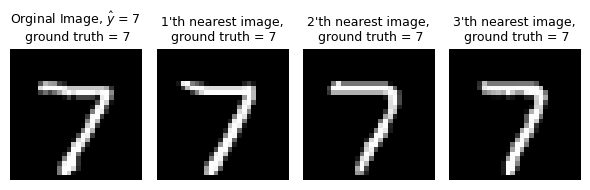

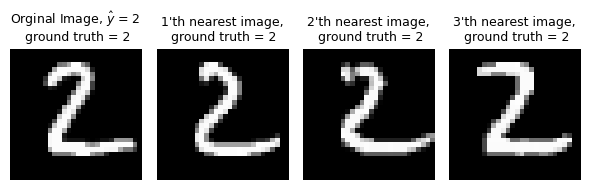

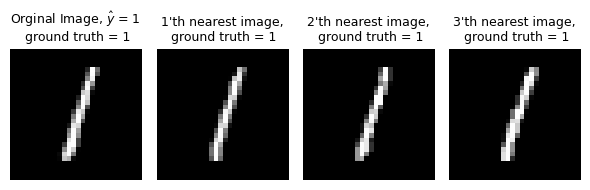

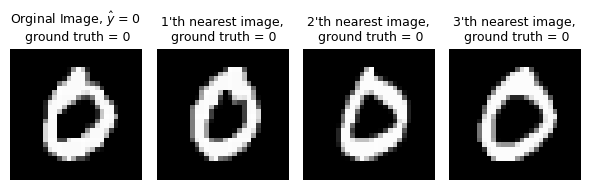

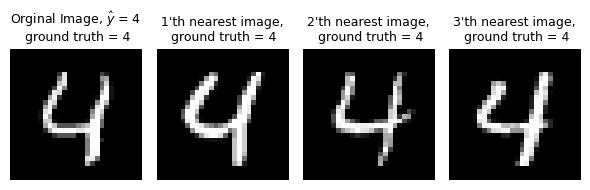

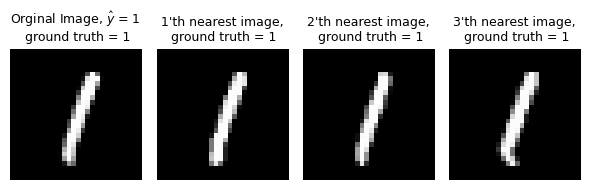

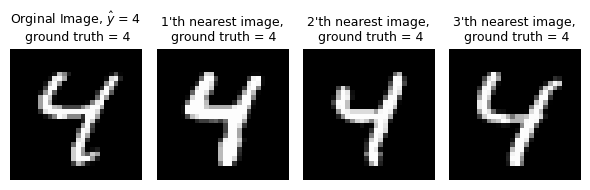

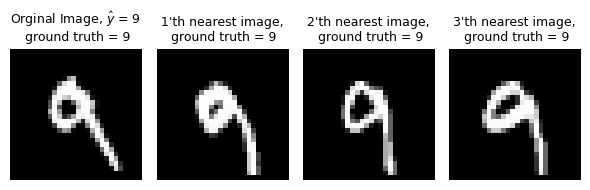

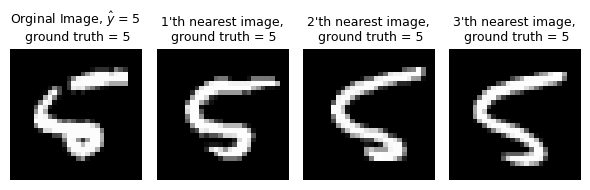

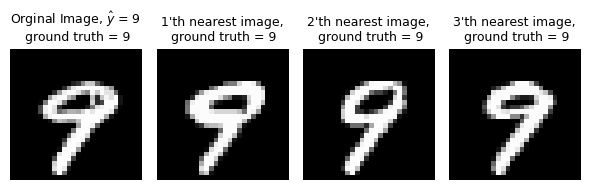

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


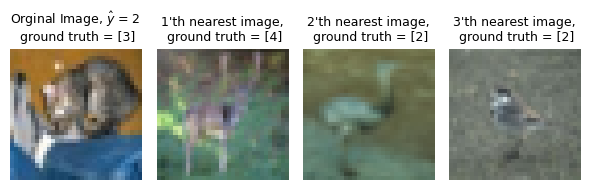

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


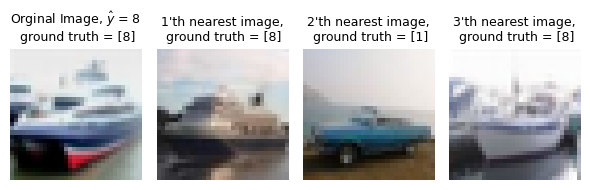

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


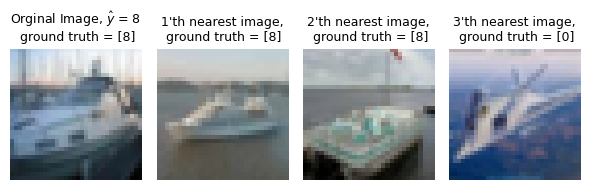

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


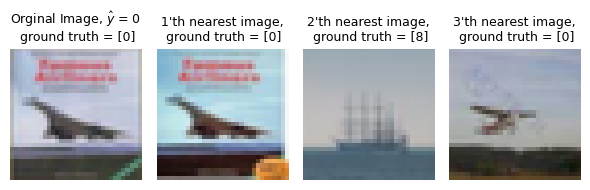

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


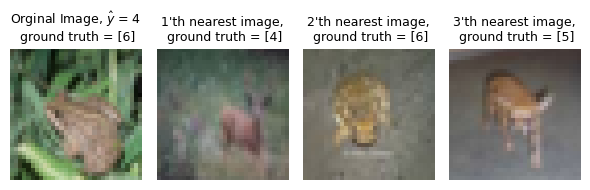

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


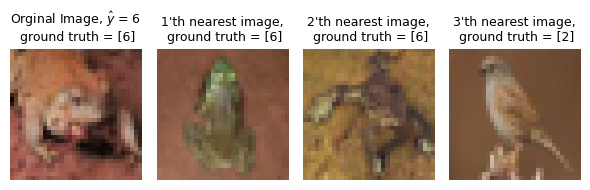

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


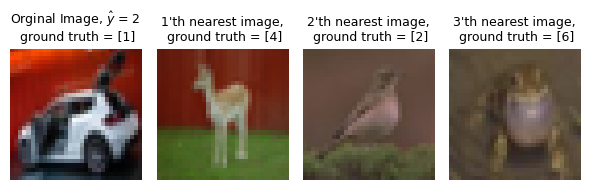

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


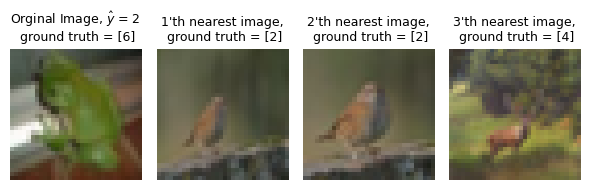

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


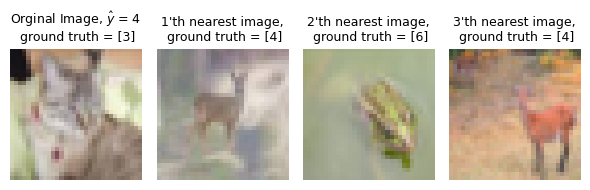

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


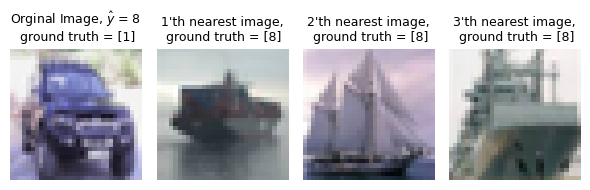

In [ ]:
for j in range(10):
  plot_k_nearest_images(np.array([mnist_test_x[j]]), np.array([mnist_test_ground_truth[j]]), 3)

for j in range(10):
  plot_k_nearest_images(np.array([cifar10_test_x[j]]), np.array([cifar10_test_ground_truth[j]]), 3, "cifar10")

We see now clearly why the images classifies as they do. More background noise and simmular colors cifar hard to reapeat very likly image.

Unneasasary on A100 but can be good

In [ ]:
# for RAM
train_x_normilized = None#mnist_train_x_normilized[:, :, :, np.newaxis]
train_ground_truth = None#mnist_train_ground_truth
test_x_normilized = None
test_ground_truth = None
train_x, validation_x, train_y, validation_y = None, None, None, None
mnist_train_x = None
mnist_test_x = None

mnist_train_x_normilized = None
mnist_test_x_normilized = None
cifar10_train_x = None

mean_cifar10_train_x =None
std_cifar10_train_x = None

cifar10_train_x_normilized =None
cifar10_test_x_normilized = None
mnist_train_x, mnist_train_ground_truth, mnist_test_x, mnist_test_ground_truth = None, None, None, None

cifar10_train_x, cifar10_train_ground_truth, cifar10_test_x, cifar10_test_ground_truth = None, None, None, None

# Extra assigment

very very long code but its because of ram and different filters and runtimes and storage. Don't need to explain again first all neassasary packages

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances
from skimage.feature import hog

import tensorflow as tf
from tensorflow.keras import layers, models, ops

from tensorflow.keras.datasets import mnist, cifar10
from tqdm import tqdm


All funny fnction idf weights istogram by counts for bad clustering. Normilize histogram normilizes the histograms, get Hog return the hog features for a image with provided strides for overlaping patterns. I have learn exactly how hog work but i dont have time to explain it here with histograms of gradients for each raw pixel and in bins of number of oriontations and weights for a patch. Hog made seperate for different colors. image to patches extract all patches in a big batch and get features return all features as a multi vector by the input. Convert to histogram predicts the nearest neigbors per feature and cluster them.  fit kmean fit the different clusters and then we have short function and clear. Importent disccusion later.

In [ ]:
def calculates_idf(histograms, exponent=1.2, alpha = 1e-6):
    num_clusters = histograms.shape[1]
    num_images = histograms.shape[0]

    n_k = np.zeros((num_clusters), dtype=np.int32)

    for image_idx in range(num_images):
        unique_clusters = np.where(histograms[image_idx] > 0)[0]
        n_k[unique_clusters] += 1

    idf = (np.log(1 + num_images / (1 + n_k))) ** exponent
    idf = np.clip(idf, alpha, None)

    return idf.astype(np.float32)

def normalize_hist(histogram, idf=None, sqrt_norm=False, normilization = "l2"):
  if idf is not None:
    histogram *= idf
  if normilization == "l1":
    histogram /= np.clip(np.sum(histogram, axis=1, keepdims=True), 1e-10, None)
  if sqrt_norm ==True:
    histogram = np.sqrt(histogram)
  if normilization == "l2":
    histogram /= np.clip(np.linalg.norm(histogram, axis=1, keepdims=True), 1e-10, None)

  return histogram

def getHog(image, amount_of_colors = 3, pixels_per_cell = (4,4),  orientations=9, cells_per_block= (1,1), patch_size = (1,1), strides= (1,1), dxs = [0, 2, 4], dys = [0, 2, 4]):
  hog_patterns = []
  size_feature_one_color = cells_per_block[0] * cells_per_block[1] * orientations
  for dx in dxs:
    for dy in dys:
      sifted_image = image[dy:,dx:,:]
      one_shift = []
      for c in range(amount_of_colors):
        hog_one_color = hog(sifted_image[:,:,c],
                          orientations=orientations,
                          pixels_per_cell=pixels_per_cell,
                          cells_per_block=cells_per_block,
                          block_norm='L2-Hys',
                          feature_vector=False,
                          transform_sqrt=True)
        n_blocks_y_real, n_blocks_x_real = hog_one_color.shape[:2]

        hog_one_color = hog_one_color.reshape((1,n_blocks_y_real, n_blocks_x_real, size_feature_one_color))
        one_shift.append(hog_one_color)
      all_colors = np.concatenate(one_shift, axis=-1)
      patches = ops.image.extract_patches(all_colors, size = (patch_size[0], patch_size[1]), strides = [1, strides[0], strides[1], 1], padding='valid').numpy()
      patches = patches.reshape((-1, amount_of_colors* size_feature_one_color *patch_size[0]* patch_size[1]))
      if amount_of_colors == 3:
        patches /= np.sum(patches, axis=-1, keepdims=True) + 1e-10
        patches = np.sqrt(patches)
        patches /= np.linalg.norm(patches, axis=-1, keepdims=True) + 1e-10

      hog_patterns.append(patches)
  hog_patterns = np.vstack(hog_patterns)
  return hog_patterns

def image_to_pacthes(images, hyper_params={}):
    """
    patches: shape (num_patches, h, w, 3)
    returns: shape (num_patches, hog_dim)
    """

    amount_of_images = images.shape[0]

    cells_per_block = hyper_params.get("cells_per_block")
    orientations = hyper_params.get("orientations")

    number_of_color = hyper_params.get("number_of_color")
    patch_size = hyper_params.get("patch_size")
    strides = hyper_params.get("strides")
    pixels_per_cell = hyper_params.get("pixels_per_cell")
    dxs = hyper_params.get("delta_x")
    dys = hyper_params.get("delta_y")

    first_hog = getHog(images[0,:,:,:], amount_of_colors = number_of_color, pixels_per_cell = pixels_per_cell,  orientations=orientations, cells_per_block= cells_per_block, patch_size=patch_size, strides=strides, dxs=dxs, dys=dys).astype(np.float32)
    hog_map = np.zeros((amount_of_images, first_hog.shape[0], first_hog.shape[1]), dtype=np.float32)
    #print(first_hog.shape)
    range_a_o_i = np.arange(amount_of_images, dtype=int)
    for p in tqdm(range_a_o_i, leave=False):
        #if p%1000==0:
          #print(p)
        hog_map[p] = getHog(images[p,:,:,:], amount_of_colors = number_of_color, pixels_per_cell = pixels_per_cell,  orientations=orientations, cells_per_block= cells_per_block, patch_size=patch_size, strides=strides, dxs=dxs, dys=dys).astype(np.float32)

    return hog_map

def convert_to_histogram(kmean_model, patches):
  # sizes patches (P, F)
  # sizes features (K, F)
  nearest_features = kmean_model.predict(patches)
  non_normilize_hist = np.bincount(nearest_features, minlength = kmean_model.n_clusters).astype(np.float64)

  non_normilize_hist /= patches.shape[0]
  #non_normilize_hist = np.sqrt(non_normilize_hist)
  #non_normilize_hist /= np.linalg.norm(non_normilize_hist)

  return non_normilize_hist

def extract_feuteres(training_data, strides = (2,2), patch_size = (8,8), pixels_per_cell=(4,4), cells_per_block = (1,1), orientations = 8, delta_x = [0], delta_y=[0]):
  if training_data.ndim == 4:
    if training_data.shape[3] == 3:
      number_of_color = 3
    else:
      number_of_color = 1
  else:
    number_of_color = 1

  batch_size = 5000

  number_of_images = training_data.shape[0]

  features_per_block = cells_per_block[0] * cells_per_block[1] * orientations * number_of_color

  first_hog = getHog(training_data[0,:,:,:], amount_of_colors = number_of_color, pixels_per_cell = pixels_per_cell,  orientations=orientations, cells_per_block= cells_per_block, patch_size=patch_size, strides=strides, dxs=delta_x, dys=delta_y).astype(np.float32)
  print(first_hog.shape)
  number_of_patches_per_images = first_hog.shape[0]
  deep_patch = first_hog.shape[1]

  patches_map = np.zeros((number_of_images, number_of_patches_per_images, deep_patch), dtype=np.float32)

  print(number_of_images, number_of_patches_per_images, deep_patch)

  hyper_params = {"orientations": orientations,
                  "pixels_per_cell": pixels_per_cell,
                  "cells_per_block": cells_per_block,
                  "number_of_color": number_of_color,
                  "patch_size": patch_size,
                  "strides":strides,
                  "delta_x":delta_x,
                  "delta_y":delta_y}



  for batch_index in range(int(np.ceil(number_of_images/batch_size))):
    lower_index_data = batch_index * batch_size
    upper_index_data = min(lower_index_data + batch_size, number_of_images)



    #print(lower_index_data)

    image_map_small = training_data[lower_index_data: upper_index_data]

    #image_map_mean = np.mean(image_map_small, axis = (1,2,3), keepdims=True)
    #image_map_std = np.std(image_map_small, axis = (1,2,3), keepdims=True)
    #image_map_small = (image_map_small - image_map_mean) / image_map_std

    patches_map[lower_index_data: upper_index_data, :, :] = image_to_pacthes(image_map_small, hyper_params )

  #patches_map = patches_map.reshape((training_data.shape[0], number_of_patches_per_images, size_features))
  print(f"shape, patches map : {patches_map.shape}\nsize : {patches_map.shape}")

  return patches_map

def fit_kmean_model(patches_map, amount_of_clusters = 128, num_samples=50000):
  flatten_patches_map = patches_map.reshape((-1, patches_map.shape[-1]))

  kmean_model = MiniBatchKMeans(amount_of_clusters, verbose=1, batch_size = 40000, n_init=10, max_iter = 10000, tol = 1e-8, random_state=13, max_no_improvement = 100)

  kmean_model.fit(flatten_patches_map)

  return kmean_model

def generate_histograms(kmean_model, patches_map, amount_of_clusters = 128, batch_size= 1000):
  number_of_images = patches_map.shape[0]

  # define F
  size_of_feature_of_patch = patches_map.shape[2]

  histograms = np.zeros((number_of_images, amount_of_clusters))

  for batch_index in range(int(np.ceil(patches_map.shape[0]/batch_size))):
    lower_index_data = batch_index * batch_size
    upper_index_data = min(lower_index_data + batch_size, patches_map.shape[0])

    for index in range(lower_index_data, upper_index_data):
      histograms[index, :] = convert_to_histogram(kmean_model, patches_map[index, :, :])

  return histograms

def train_network(training_labels, histograms_training, number_of_neigbors = 3):
  if training_labels.ndim == 2:
    training_labels = training_labels[:,0]

  k_nearest_neigbors = KNeighborsClassifier(number_of_neigbors, metric = "euclidean")

  k_nearest_neigbors.fit(histograms_training, training_labels)

  return k_nearest_neigbors

def predict_histograms(histograms, k_nearest_neigbors):
  predicted_images = k_nearest_neigbors.predict(histograms)
  return predicted_images

def get_accurrucy(ground_truth, infered_label):
  return np.mean(ground_truth == infered_label)








Package to save histograms but we don't use it here (outcomented)

In [ ]:
if False:
  import numpy as np
  import json
  from google.colab import files
  import joblib

def convert_array_to_dict(array):
  array = np.array(array, dtype=np.float32)
  data = {
    "shape": array.shape,
    "dtype": str(array.dtype),
    "data": array.tolist()
  }
  return data

def dumpa(data, file_name = "histogram_3_3.json"):
  with open(file_name, "w") as f:
    json.dump(data, f)

def loada(file_name = "histogram_3_3.json"):
  with open(file_name, "r") as f:
    loaded_data = json.load(f)
  return loaded_data

def convert_dict_to_array(dict_loaded):
  loaded_array = np.array(
    dict_loaded["data"],
    dtype=dict_loaded["dtype"]
  ).reshape(dict_loaded["shape"])

def download_file(dictionarray):
  files.download(dictionarray)

def dumpa_model(model, model_file_name):
    joblib.dump(model, model_file_name)

def loada_model(file_name):
  model = joblib.load(file_name)
  return model


## Mist
### first histogram make
4,4 pxt per cell and 3 cells per block observe that patch and stride here is one because I made a different choice in structure because I didn't first not how cells work but they are simular. all patch and stride is 1 and dosnt effect the code. We cant get all delta y because of ram.

In [ ]:
(mnist_train_x, mnist_train_ground_truth), (mnist_test_x, mnist_test_ground_truth) = mnist.load_data()

mnist_train_x = mnist_train_x.astype("float")
mnist_test_x = mnist_test_x.astype("float")

mnist_train_x_normilized = mnist_train_x/255.
mnist_test_x_normilized = mnist_test_x/255.
print(mnist_train_x_normilized.ndim)

mnist_train_x_normilized = mnist_train_x_normilized[:, :, :, np.newaxis]
mnist_test_x_normilized = mnist_test_x_normilized[:, :, :, np.newaxis]

del mnist_train_x
del mnist_test_x

3


In [ ]:
patch_size_mnist = (1, 1)
stride_mnist = (1, 1)
pixels_per_cell_mnist = (4,4)
cells_per_block_mnist = (3,3)
orientations_mnist = 9
delta_x = [0, 2]
delta_y = [0, 2]
mnist_patches_map = extract_feuteres(mnist_train_x_normilized,
                                       patch_size = patch_size_mnist,
                                       strides = stride_mnist,
                                       pixels_per_cell = pixels_per_cell_mnist,
                                       cells_per_block = cells_per_block_mnist,
                                       orientations = orientations_mnist,
                                       delta_x = delta_x,
                                       delta_y=delta_y)

(81, 81)
60000 81 81


shape, patches map : (60000, 81, 81)
size : (60000, 81, 81)


build 256 clusters

In [ ]:
amount_of_clusters_mnist = 256
mnist_kmean_model = fit_kmean_model(mnist_patches_map, amount_of_clusters = amount_of_clusters_mnist, num_samples = 50000)

Init 1/10 with method k-means++
Inertia for init 1/10: 62668.4296875
Init 2/10 with method k-means++
Inertia for init 2/10: 62633.25390625
Init 3/10 with method k-means++
Inertia for init 3/10: 62621.13671875
Init 4/10 with method k-means++
Inertia for init 4/10: 62672.078125
Init 5/10 with method k-means++
Inertia for init 5/10: 62779.5625
Init 6/10 with method k-means++
Inertia for init 6/10: 62679.421875
Init 7/10 with method k-means++
Inertia for init 7/10: 62535.12890625
Init 8/10 with method k-means++
Inertia for init 8/10: 62777.3125
Init 9/10 with method k-means++
Inertia for init 9/10: 62588.76171875
Init 10/10 with method k-means++
Inertia for init 10/10: 62814.5859375
Minibatch step 1/1215000: mean batch inertia: 0.522906640625
Minibatch step 2/1215000: mean batch inertia: 0.371107421875, ewa inertia: 0.371107421875
Minibatch step 3/1215000: mean batch inertia: 0.365885693359375, ewa inertia: 0.3710214675138281
Minibatch step 4/1215000: mean batch inertia: 0.36363564453125, 

### second histogram beginning.
This one extract higher features (importent) to get a new histogram (importent that the size is good for information also).

In [ ]:
patch_size_mnist_big = (1, 1)
stride_mnist_big = (1, 1)
pixels_per_cell_mnist_big = (6,6)
cells_per_block_mnist_big = (2,2)
orientations_mnist_big = 9
delta_x_big = [0, 2]
delta_y_big = [0, 2]
mnist_patches_map_big = extract_feuteres(mnist_train_x_normilized,
                                       patch_size = patch_size_mnist_big,
                                       strides = stride_mnist_big,
                                       pixels_per_cell = pixels_per_cell_mnist_big,
                                       cells_per_block = cells_per_block_mnist_big,
                                       orientations = orientations_mnist_big,
                                       delta_x = delta_x_big,
                                       delta_y=delta_y_big)

(36, 36)
60000 36 36


shape, patches map : (60000, 36, 36)
size : (60000, 36, 36)


In [ ]:
amount_of_clusters_mnist_big = 256
mnist_kmean_model_big = fit_kmean_model(mnist_patches_map_big, amount_of_clusters = amount_of_clusters_mnist_big, num_samples = 50000)

Init 1/10 with method k-means++
Inertia for init 1/10: 35971.48046875
Init 2/10 with method k-means++
Inertia for init 2/10: 35782.97265625
Init 3/10 with method k-means++
Inertia for init 3/10: 35642.08984375
Init 4/10 with method k-means++
Inertia for init 4/10: 35912.8125
Init 5/10 with method k-means++
Inertia for init 5/10: 35711.07421875
Init 6/10 with method k-means++
Inertia for init 6/10: 35554.3515625
Init 7/10 with method k-means++
Inertia for init 7/10: 35707.796875
Init 8/10 with method k-means++
Inertia for init 8/10: 35742.36328125
Init 9/10 with method k-means++
Inertia for init 9/10: 35541.00390625
Init 10/10 with method k-means++
Inertia for init 10/10: 35859.38671875
Minibatch step 1/540000: mean batch inertia: 0.2955930419921875
Minibatch step 2/540000: mean batch inertia: 0.2254095947265625, ewa inertia: 0.2254095947265625
Minibatch step 3/540000: mean batch inertia: 0.2229837890625, ewa inertia: 0.2253197501139327
Minibatch step 4/540000: mean batch inertia: 0.220

Here do we make the test features also to inizilize them.

In [ ]:
mnist_patches_map_test = extract_feuteres(mnist_test_x_normilized,
                                       patch_size = patch_size_mnist,
                                       strides = stride_mnist,
                                       pixels_per_cell = pixels_per_cell_mnist,
                                       cells_per_block = cells_per_block_mnist,
                                       orientations = orientations_mnist,
                                       delta_x = delta_x,
                                       delta_y = delta_y)


(81, 81)
10000 81 81


shape, patches map : (10000, 81, 81)
size : (10000, 81, 81)


In [ ]:
mnist_patches_map_test_big = extract_feuteres(mnist_test_x_normilized,
                                       patch_size = patch_size_mnist_big,
                                       strides = stride_mnist_big,
                                       pixels_per_cell = pixels_per_cell_mnist_big,
                                       cells_per_block = cells_per_block_mnist_big,
                                       orientations = orientations_mnist_big,
                                       delta_x = delta_x_big,
                                       delta_y = delta_y_big)

(36, 36)
10000 36 36


shape, patches map : (10000, 36, 36)
size : (10000, 36, 36)


Start first diagram and deleye old data

In [ ]:
mnist_train_hist_small = generate_histograms(mnist_kmean_model, mnist_patches_map, amount_of_clusters = amount_of_clusters_mnist)
mnist_test_hist_small = generate_histograms(mnist_kmean_model, mnist_patches_map_test, amount_of_clusters = amount_of_clusters_mnist)

In [ ]:
del mnist_patches_map
del mnist_patches_map_test

Get alll strides that isnät in the first patch to create maximum number of patches from features sizes. Easy to understand for me this part when I tried to achive a so high accurrucy as posiblem this way to create patches and add to the histograms on already created histogram (observe mnist_train_hist_small m.m is numpy). We get a better and better histogram. Observe that importent to not by mistake rereun something and add a histogram to much

In [ ]:
if True:
  for delta_x_l in [0, 1, 2, 3]:
    for delta_y_l in [0, 1, 2, 3]:
      if (delta_x_l not in delta_x)  or (delta_y_l not in delta_y):
        print(delta_x_l, delta_y_l)
        mnist_patches_map = extract_feuteres(mnist_train_x_normilized,
                                        patch_size = patch_size_mnist,
                                        strides = stride_mnist,
                                        pixels_per_cell = pixels_per_cell_mnist,
                                        cells_per_block = cells_per_block_mnist,
                                        orientations = orientations_mnist,
                                        delta_x = [delta_x_l],
                                        delta_y= [delta_y_l])
        mnist_train_hist_small += generate_histograms(mnist_kmean_model, mnist_patches_map, amount_of_clusters = amount_of_clusters_mnist)

        mnist_patches_map_test = extract_feuteres(mnist_test_x_normilized,
                                        patch_size = patch_size_mnist,
                                        strides = stride_mnist,
                                        pixels_per_cell = pixels_per_cell_mnist,
                                        cells_per_block = cells_per_block_mnist,
                                        orientations = orientations_mnist,
                                        delta_x = [delta_x_l],
                                        delta_y= [delta_y_l])

        mnist_test_hist_small += generate_histograms(mnist_kmean_model, mnist_patches_map_test, amount_of_clusters = amount_of_clusters_mnist)


0 1
(20, 81)
60000 20 81


shape, patches map : (60000, 20, 81)
size : (60000, 20, 81)
(20, 81)
10000 20 81


shape, patches map : (10000, 20, 81)
size : (10000, 20, 81)
0 3
(20, 81)
60000 20 81


shape, patches map : (60000, 20, 81)
size : (60000, 20, 81)
(20, 81)
10000 20 81


shape, patches map : (10000, 20, 81)
size : (10000, 20, 81)
1 0
(20, 81)
60000 20 81


...

shape, patches map : (10000, 16, 81)
size : (10000, 16, 81)
3 2
(16, 81)
60000 16 81


shape, patches map : (60000, 16, 81)
size : (60000, 16, 81)
(16, 81)
10000 16 81


shape, patches map : (10000, 16, 81)
size : (10000, 16, 81)
3 3
(16, 81)
60000 16 81


shape, patches map : (60000, 16, 81)
size : (60000, 16, 81)
(16, 81)
10000 16 81


shape, patches map : (10000, 16, 81)
size : (10000, 16, 81)


Idf for bad batching we plott to se so log values with exponent ... a function. We see that we have good cluster not diverge values. This is importent beacuse we uuse new images with stride that affect the clustering. Then we aplied the sqrt_norm here and make a sqrt + L2 normilization to combat high values and get a unit vector as histogram. Normilization is **VERY** important to achive the more higher accurrucy. Can be big differences.

In [ ]:
idf = calculates_idf(mnist_train_hist_small)
print(idf)
mnist_train_hist_normilized_s = normalize_hist(mnist_train_hist_small, sqrt_norm = True, normilization="L2")
mnist_test_hist_normilized_s = normalize_hist(mnist_test_hist_small, sqrt_norm = True, normilization="L2")

[1.8276569 2.5772126 1.9780858 1.4591942 1.719934  1.5714625 2.3236444
 1.4240414 1.5314673 2.136201  1.5801255 1.6223795 2.306201  1.4345856
 2.4594872 2.1914902 2.2884343 2.1398513 2.0654736 2.5302618 1.6072482
 1.8901701 1.6228464 1.5698291 2.1594195 2.287052  1.967798  2.0974813
 2.3498008 2.9301035 1.7330017 1.5148313 1.9447148 1.8218644 1.7871455
 1.8595876 1.871593  1.8357737 2.008756  1.9354099 1.4647672 2.0485668
 1.3791364 2.0698497 1.4761431 2.2055755 1.5961233 2.2546968 2.543624
 2.04633   1.8922051 1.8801475 1.5338975 1.9323304 2.0774584 1.5185235
 1.8121016 2.1833413 1.684438  1.8240412 1.847596  2.2093904 1.8715135
 1.9892237 1.9827774 2.8341641 2.015864  1.7173592 2.1502366 1.6687291
 1.9175982 1.3830898 1.8241916 1.2352784 1.942552  1.6182492 1.9104087
 1.8550512 1.7528744 2.2910788 2.4498277 1.8780608 1.5175606 1.9402221
 1.7889442 2.203271  1.9077489 2.925026  1.8325022 1.56495   2.0141754
 2.7493987 1.4666976 1.7416525 2.1426525 1.5428609 1.8622582 2.4647267
 1.4362

We make the same for the bigger histogram

In [ ]:
mnist_train_hist_big = generate_histograms(mnist_kmean_model_big, mnist_patches_map_big, amount_of_clusters = amount_of_clusters_mnist_big)
mnist_test_hist_big = generate_histograms(mnist_kmean_model_big, mnist_patches_map_test_big, amount_of_clusters = amount_of_clusters_mnist_big)


In [ ]:
del mnist_patches_map_big
del mnist_patches_map_test_big

Her we don't use all of the strides first.

In [ ]:
if True:
  for delta_x_big_l in [0, 2, 4]:
    for delta_y_big_l in [0, 2, 4]:
      if (delta_x_big_l not in delta_x_big)  or (delta_y_big_l not in delta_y_big):
        print(delta_x_big_l, delta_y_big_l)
        mnist_patches_map_big = extract_feuteres(mnist_train_x_normilized,
                                        patch_size = patch_size_mnist_big,
                                        strides = stride_mnist_big,
                                        pixels_per_cell = pixels_per_cell_mnist_big,
                                        cells_per_block = cells_per_block_mnist_big,
                                        orientations = orientations_mnist_big,
                                        delta_x = [delta_x_big_l],
                                        delta_y = [delta_y_big_l])
        mnist_train_hist_big += generate_histograms(mnist_kmean_model_big, mnist_patches_map_big, amount_of_clusters = amount_of_clusters_mnist_big)

        mnist_patches_map_test_big = extract_feuteres(mnist_test_x_normilized,
                                        patch_size = patch_size_mnist_big,
                                        strides = stride_mnist_big,
                                        pixels_per_cell = pixels_per_cell_mnist_big,
                                        cells_per_block = cells_per_block_mnist_big,
                                        orientations = orientations_mnist_big,
                                        delta_x = [delta_x_big_l],
                                        delta_y = [delta_y_big_l])

        mnist_test_hist_big += generate_histograms(mnist_kmean_model_big, mnist_patches_map_test_big, amount_of_clusters = amount_of_clusters_mnist_big)


0 4
(9, 36)
60000 9 36


shape, patches map : (60000, 9, 36)
size : (60000, 9, 36)
(9, 36)
10000 9 36


shape, patches map : (10000, 9, 36)
size : (10000, 9, 36)
2 4
(9, 36)
60000 9 36


shape, patches map : (60000, 9, 36)
size : (60000, 9, 36)
(9, 36)
10000 9 36


shape, patches map : (10000, 9, 36)
size : (10000, 9, 36)
4 0
(9, 36)
60000 9 36


...

shape, patches map : (10000, 9, 36)
size : (10000, 9, 36)
4 2
(9, 36)
60000 9 36


shape, patches map : (60000, 9, 36)
size : (60000, 9, 36)
(9, 36)
10000 9 36


shape, patches map : (10000, 9, 36)
size : (10000, 9, 36)
4 4
(9, 36)
60000 9 36


shape, patches map : (60000, 9, 36)
size : (60000, 9, 36)
(9, 36)
10000 9 36


shape, patches map : (10000, 9, 36)
size : (10000, 9, 36)


If you have time and want to achive an  even hugher accurrucy by more patches (I dont use it here).

In [ ]:
if False:
  for delta_x_big_l in [0, 1, 2, 3, 4, 5]:
    for delta_y_big_l in [0, 1, 2, 3, 4, 5]:
      if (delta_x_big_l not in [0, 2, 4])  or (delta_y_big_l not in [0, 2, 4]):
        print(delta_x_big_l, delta_y_big_l)
        mnist_patches_map_big = extract_feuteres(mnist_train_x_normilized,
                                        patch_size = patch_size_mnist_big,
                                        strides = stride_mnist_big,
                                        pixels_per_cell = pixels_per_cell_mnist_big,
                                        cells_per_block = cells_per_block_mnist_big,
                                        orientations = orientations_mnist_big,
                                        delta_x = [delta_x_big_l],
                                        delta_y = [delta_y_big_l])
        mnist_train_hist_big += generate_histograms(mnist_kmean_model_big, mnist_patches_map_big, amount_of_clusters = amount_of_clusters_mnist_big)

        mnist_patches_map_test_big = extract_feuteres(mnist_test_x_normilized,
                                        patch_size = patch_size_mnist_big,
                                        strides = stride_mnist_big,
                                        pixels_per_cell = pixels_per_cell_mnist_big,
                                        cells_per_block = cells_per_block_mnist_big,
                                        orientations = orientations_mnist_big,
                                        delta_x = [delta_x_big_l],
                                        delta_y = [delta_y_big_l])

        mnist_test_hist_big += generate_histograms(mnist_kmean_model_big, mnist_patches_map_test_big, amount_of_clusters = amount_of_clusters_mnist_big)

Normilization same obs note that the histogram don't have been undergoing any L2 normilization before in making. L1 normilization dosn't affect no much.

In [ ]:
idf = calculates_idf(mnist_train_hist_big)
print(idf)
mnist_train_hist_normilized_big = normalize_hist(mnist_train_hist_big, sqrt_norm = True, normilization="L2")
mnist_test_hist_normilized_big = normalize_hist(mnist_test_hist_big, sqrt_norm = True, normilization="L2")

[1.9991204 2.2909527 2.0695508 1.9688659 2.4786286 2.6260135 2.018968
 2.4056928 2.1725845 2.6204205 2.52643   2.1821024 2.3640935 2.1153276
 1.72451   2.0910301 2.5966332 2.7790854 2.7233741 2.7752547 2.2781768
 1.693339  2.1132345 1.8577857 2.566724  2.4386487 1.8047993 1.8722296
 3.4686759 2.361923  2.2888117 1.7636957 2.638707  2.0702486 2.4650269
 2.9534743 2.1466537 3.3034415 2.642082  3.5250227 1.8899262 2.5400653
 2.2717276 2.4822865 2.066665  3.5143788 2.2557905 2.2148502 1.9070023
 2.5979977 2.576042  1.9718094 2.8812168 2.523883  2.4245577 2.762648
 2.0161457 1.7354254 2.5494733 2.5747058 2.3830144 3.1327937 2.1034606
 2.705484  2.555192  2.0052233 2.5545368 2.6839926 1.908164  3.3095083
 2.0414858 2.275195  1.7936398 1.5993418 2.06181   3.1717799 1.9042703
 3.164672  2.82718   3.5493102 2.4329596 2.252392  2.1169004 2.233437
 2.934739  2.5262706 2.0417757 2.1027367 3.054901  2.3607042 2.475287
 1.9884039 2.590176  2.4461367 1.7974156 2.3551702 2.252271  2.5433
 1.8963717 1.

combine the histogram (note factor 0.5 same weight both histogram always nearly better (no bias else the effect of using different sizes vanish)).

In [ ]:
u = 0.5
factor_1 = (u)/np.sqrt(u**2 + (1 - u)**2)
factor_2 = (1-u)/np.sqrt(u**2 + (1 - u)**2)
mnist_train_hist_normilized = np.concatenate((factor_1 * mnist_train_hist_normilized_s, factor_2 * mnist_train_hist_normilized_big), axis=1)
mnist_test_hist_normilized = np.concatenate((factor_1 * mnist_test_hist_normilized_s, factor_2 * mnist_test_hist_normilized_big), axis=1)


calculates the accurrucy for mnist and note that k = 1 or 3 gives like before the best accurrucy and yes the combine digram better and note important that because of we used all strides for histogram 1 which gives us the much higher accurrucyn. If we use all strides we get even better results.

In [ ]:
for mnist_neighbors in [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]:
#  mnist_neighbors = 5
  for model in [[mnist_train_hist_normilized_s, mnist_test_hist_normilized_s],[mnist_train_hist_normilized_big, mnist_test_hist_normilized_big],[mnist_train_hist_normilized, mnist_test_hist_normilized]]:
    mnist_nearest_neigbor_model = train_network(mnist_train_ground_truth, model[0], mnist_neighbors)

    mnist_infered_label = predict_histograms(model[1], mnist_nearest_neigbor_model)

    mnist_accurucy_test = get_accurrucy(mnist_test_ground_truth, mnist_infered_label)
    print(f"neigbors {mnist_neighbors} : accuruccy {mnist_accurucy_test}")

neigbors 1 : accuruccy 0.9776
neigbors 1 : accuruccy 0.963
neigbors 1 : accuruccy 0.9795
neigbors 3 : accuruccy 0.9776
neigbors 3 : accuruccy 0.9644
neigbors 3 : accuruccy 0.979
neigbors 5 : accuruccy 0.9764
neigbors 5 : accuruccy 0.9659
neigbors 5 : accuruccy 0.978
neigbors 7 : accuruccy 0.9759
neigbors 7 : accuruccy 0.9664
neigbors 7 : accuruccy 0.978
neigbors 9 : accuruccy 0.9749
neigbors 9 : accuruccy 0.9647
neigbors 9 : accuruccy 0.9782
neigbors 11 : accuruccy 0.9739
neigbors 11 : accuruccy 0.9658
neigbors 11 : accuruccy 0.9772
neigbors 13 : accuruccy 0.973
neigbors 13 : accuruccy 0.9644
neigbors 13 : accuruccy 0.9754
neigbors 15 : accuruccy 0.9729
neigbors 15 : accuruccy 0.9636
neigbors 15 : accuruccy 0.9754
neigbors 17 : accuruccy 0.9726
neigbors 17 : accuruccy 0.963
neigbors 17 : accuruccy 0.9748
neigbors 19 : accuruccy 0.9727
neigbors 19 : accuruccy 0.9628
neigbors 19 : accuruccy 0.9745


Kör och printar final accurrucyn. Ingen valideringset på den här då det är för för kostsamt.

In [ ]:
mnist_nearest_neigbor_model = train_network(mnist_train_ground_truth, mnist_train_hist_normilized, 1)

mnist_infered_label = predict_histograms(mnist_test_hist_normilized, mnist_nearest_neigbor_model)

mnist_accurucy_test = get_accurrucy(mnist_test_ground_truth, mnist_infered_label)

print(f"mnist accurrucy: {mnist_accurucy_test*100:.2f}%")

mnist accurrucy: 97.95%


# Cifar10 extra assigment

We do exactly the same for cifar so this one is faster but note that we have an extra dimension here and be normilize cifar10 with pixel in continus space!!!! no std or something to scale. we dont need it because of the cluster make it even.

In [ ]:
(cifar10_train_x, cifar10_train_ground_truth), (cifar10_test_x, cifar10_test_ground_truth) = cifar10.load_data()

cifar10_train_x = cifar10_train_x.astype("float")
cifar10_test_x = cifar10_test_x.astype("float")

#mean_cifar10_train_x = np.mean(cifar10_train_x, axis=(0,1,2), keepdims=True)
#std_cifar10_train_x = np.std(cifar10_train_x, axis=(0,1,2), keepdims=True)

cifar10_train_x_normilized = cifar10_train_x/255.# - mean_cifar10_train_x) / std_cifar10_train_x
cifar10_test_x_normilized = cifar10_test_x/255.# - mean_cifar10_train_x) / std_cifar10_train_x

cifar10_train_ground_truth = cifar10_train_ground_truth.flatten()
cifar10_test_ground_truth = cifar10_test_ground_truth.flatten()

del cifar10_train_x
del cifar10_test_x


very large features extracted instead here

In [ ]:
patch_size_cifar10 = (1, 1)
stride_cifar10 = (1, 1)
pixels_per_cell_cifar10 = (8, 8)
cells_per_block_cifar10 = (2, 2)
orientations_cifar10 = 9
delta_cifar10_x = [0]
delta_cifar10_y = [0]

cifar10_patches_map = extract_feuteres(cifar10_train_x_normilized,
                                       patch_size = patch_size_cifar10,
                                       strides = stride_cifar10,
                                       pixels_per_cell = pixels_per_cell_cifar10,
                                       cells_per_block = cells_per_block_cifar10,
                                       orientations = orientations_cifar10,
                                       delta_x = delta_cifar10_x,
                                       delta_y = delta_cifar10_y)

(9, 108)
50000 9 108


shape, patches map : (50000, 9, 108)
size : (50000, 9, 108)


more is more for clustters

In [ ]:
amount_of_clusters_cifar10 = 400
cifar10_kmean_model = fit_kmean_model(cifar10_patches_map, amount_of_clusters = amount_of_clusters_cifar10, num_samples = 20000)

Init 1/10 with method k-means++
Inertia for init 1/10: 14090.7314453125
Init 2/10 with method k-means++
Inertia for init 2/10: 14180.8134765625
Init 3/10 with method k-means++
Inertia for init 3/10: 14154.4228515625
Init 4/10 with method k-means++
Inertia for init 4/10: 14166.55859375
Init 5/10 with method k-means++
Inertia for init 5/10: 14036.82421875
Init 6/10 with method k-means++
Inertia for init 6/10: 14249.2587890625
Init 7/10 with method k-means++
Inertia for init 7/10: 14133.4580078125
Init 8/10 with method k-means++
Inertia for init 8/10: 14096.302734375
Init 9/10 with method k-means++
Inertia for init 9/10: 14097.80078125
Init 10/10 with method k-means++
Inertia for init 10/10: 14141.8681640625
[MiniBatchKMeans] Reassigning 5 cluster centers.
Minibatch step 1/112500: mean batch inertia: 0.11750994873046874
[MiniBatchKMeans] Reassigning 3 cluster centers.
Minibatch step 2/112500: mean batch inertia: 0.09050592041015625, ewa inertia: 0.09050592041015625
[MiniBatchKMeans] Reass

In [ ]:
cifar10_patches_map_test = extract_feuteres(cifar10_test_x_normilized,
                                       patch_size = patch_size_cifar10,
                                       strides = stride_cifar10,
                                       pixels_per_cell = pixels_per_cell_cifar10,
                                       cells_per_block = cells_per_block_cifar10,
                                       orientations = orientations_cifar10,
                                       delta_x = delta_cifar10_x,
                                       delta_y = delta_cifar10_y)

(9, 108)
10000 9 108


shape, patches map : (10000, 9, 108)
size : (10000, 9, 108)


generates histogram and below use strides to provide better results. Funny or not. Very time consuming hog on skimap is coded on cpu and did't want to write a torch hog. Will do in sunner probably.

In [ ]:
cifar10_train_hist = generate_histograms(cifar10_kmean_model, cifar10_patches_map, amount_of_clusters = amount_of_clusters_cifar10)
cifar10_test_hist = generate_histograms(cifar10_kmean_model, cifar10_patches_map_test, amount_of_clusters = amount_of_clusters_cifar10)

In [ ]:
if True:
  for delta_x_l in [0, 4]:
    for delta_y_l in [0, 4]:
      if (delta_x_l not in delta_cifar10_x)  or (delta_y_l not in delta_cifar10_y):
        print(delta_x_l, delta_y_l)
        cifar10_patches_map_train = extract_feuteres(cifar10_train_x_normilized,
                                       patch_size = patch_size_cifar10,
                                       strides = stride_cifar10,
                                       pixels_per_cell = pixels_per_cell_cifar10,
                                       cells_per_block = cells_per_block_cifar10,
                                       orientations = orientations_cifar10,
                                       delta_x = [delta_x_l],
                                       delta_y = [delta_y_l])
        cifar10_train_hist += generate_histograms(cifar10_kmean_model, cifar10_patches_map_train, amount_of_clusters = amount_of_clusters_cifar10)

        cifar10_patches_map_test = extract_feuteres(cifar10_test_x_normilized,
                                       patch_size = patch_size_cifar10,
                                       strides = stride_cifar10,
                                       pixels_per_cell = pixels_per_cell_cifar10,
                                       cells_per_block = cells_per_block_cifar10,
                                       orientations = orientations_cifar10,
                                       delta_x = [delta_x_l],
                                       delta_y = [delta_y_l])

        cifar10_test_hist += generate_histograms(cifar10_kmean_model, cifar10_patches_map_test, amount_of_clusters = amount_of_clusters_cifar10)

0 4
(6, 108)
50000 6 108


shape, patches map : (50000, 6, 108)
size : (50000, 6, 108)
(6, 108)
10000 6 108


shape, patches map : (10000, 6, 108)
size : (10000, 6, 108)
4 0
(6, 108)
50000 6 108


shape, patches map : (50000, 6, 108)
size : (50000, 6, 108)
(6, 108)
10000 6 108


shape, patches map : (10000, 6, 108)
size : (10000, 6, 108)
4 4
(4, 108)
50000 4 108


shape, patches map : (50000, 4, 108)
size : (50000, 4, 108)
(4, 108)
10000 4 108


shape, patches map : (10000, 4, 108)
size : (10000, 4, 108)


Apply idf again

In [ ]:
idf = calculates_idf(cifar10_train_hist)
print(idf)
cifar10_train_hist_normilized = normalize_hist(cifar10_train_hist, sqrt_norm = True, normilization="L2")
cifar10_test_hist_normilized = normalize_hist(cifar10_test_hist, sqrt_norm = True, normilization="L2")

[4.432667  3.0280228 3.4781969 3.7225213 4.7099056 3.8362355 2.9339962
 3.1163032 3.3685486 3.5579042 3.210036  4.224006  4.5344286 4.7065506
 3.946833  3.5176384 3.3762367 3.361711  3.4120724 3.1977289 4.311689
 3.20545   3.8205178 4.392026  4.216169  4.600122  3.9272108 2.9823635
 3.9758508 4.641084  2.8682697 4.3024936 3.8998578 4.2518024 4.7256703
 3.8338947 4.572455  3.830392  3.2196183 3.1618974 4.152083  3.4667804
 3.3549116 3.627543  4.4045405 3.5532093 5.2481284 3.7661383 5.5358534
 4.3603625 4.581616  5.2094703 3.7381608 4.277728  7.3257465 6.644882
 4.426265  4.0845447 4.750807  3.1824365 3.9366686 3.083159  3.6506274
 3.2386553 3.533681  4.3508325 3.9602945 3.1281133 4.601157  5.0317206
 3.8712618 3.9765031 3.919694  4.882426  4.176136  4.086671  3.0247004
 4.553311  3.6073184 3.1758935 3.9297264 3.9732451 3.5085633 3.6965249
 4.275276  3.510373  3.791908  3.760052  3.0743098 3.1855485 4.4926248
 4.045475  4.022981  4.029078  3.7193096 3.3087404 2.9334393 4.9551206
 3.73328

We use more local features optimal (4,4) and cells per block (2,2) give more local features so better now but not to noisy.

In [ ]:
patch_size_cifar10_b = (1, 1)
stride_cifar10_b = (1, 1)
pixels_per_cell_cifar10_b = (4, 4)
cells_per_block_cifar10_b = (2, 2)
orientations_cifar10_b = 9
delta_cifar10_x_b = [0]
delta_cifar10_y_b = [0]

cifar10_patches_map_b = extract_feuteres(cifar10_train_x_normilized,
                                       patch_size = patch_size_cifar10_b,
                                       strides = stride_cifar10_b,
                                       pixels_per_cell = pixels_per_cell_cifar10_b,
                                       cells_per_block = cells_per_block_cifar10_b,
                                       orientations = orientations_cifar10_b,
                                       delta_x = delta_cifar10_x_b,
                                       delta_y = delta_cifar10_y_b)

(49, 108)
50000 49 108


shape, patches map : (50000, 49, 108)
size : (50000, 49, 108)


Same amount of clusters safest less bias

In [ ]:
amount_of_clusters_cifar10_b = 400
cifar10_kmean_model_b = fit_kmean_model(cifar10_patches_map_b, amount_of_clusters = amount_of_clusters_cifar10_b, num_samples = 20000)

Init 1/10 with method k-means++
Inertia for init 1/10: 42769.89453125
Init 2/10 with method k-means++
Inertia for init 2/10: 42545.37109375
Init 3/10 with method k-means++
Inertia for init 3/10: 42738.14453125
Init 4/10 with method k-means++
Inertia for init 4/10: 42572.359375
Init 5/10 with method k-means++
Inertia for init 5/10: 42764.8515625
Init 6/10 with method k-means++
Inertia for init 6/10: 42954.2109375
Init 7/10 with method k-means++
Inertia for init 7/10: 42725.75390625
Init 8/10 with method k-means++
Inertia for init 8/10: 42658.71484375
Init 9/10 with method k-means++
Inertia for init 9/10: 42703.859375
Init 10/10 with method k-means++
Inertia for init 10/10: 42414.9453125
[MiniBatchKMeans] Reassigning 3 cluster centers.
Minibatch step 1/612500: mean batch inertia: 0.3534168701171875
[MiniBatchKMeans] Reassigning 3 cluster centers.
Minibatch step 2/612500: mean batch inertia: 0.2535128173828125, ewa inertia: 0.2535128173828125
Minibatch step 3/612500: mean batch inertia: 0

Make test and all of the more local patterns for test + training but note here that we here also dosn't use all strides. We obtain better results with more strides (denoted as delta x, delta y or a letter after them).

In [ ]:
cifar10_patches_map_test_b = extract_feuteres(cifar10_test_x_normilized,
                                       patch_size = patch_size_cifar10_b,
                                       strides = stride_cifar10_b,
                                       pixels_per_cell = pixels_per_cell_cifar10_b,
                                       cells_per_block = cells_per_block_cifar10_b,
                                       orientations = orientations_cifar10_b,
                                       delta_x = delta_cifar10_x_b,
                                       delta_y = delta_cifar10_y_b)

(49, 108)
10000 49 108


shape, patches map : (10000, 49, 108)
size : (10000, 49, 108)


In [ ]:
cifar10_train_hist_b = generate_histograms(cifar10_kmean_model_b, cifar10_patches_map_b, amount_of_clusters = amount_of_clusters_cifar10_b)
cifar10_test_hist_b = generate_histograms(cifar10_kmean_model_b, cifar10_patches_map_test_b, amount_of_clusters = amount_of_clusters_cifar10_b)

In [ ]:
if True:
  for delta_x_l in [0, 2]:
    for delta_y_l in [0, 2]:
      if (delta_x_l not in delta_cifar10_x_b)  or (delta_y_l not in delta_cifar10_y_b):
        print(delta_x_l, delta_y_l)
        cifar10_patches_map_b = extract_feuteres(cifar10_train_x_normilized,
                                       patch_size = patch_size_cifar10_b,
                                       strides = stride_cifar10_b,
                                       pixels_per_cell = pixels_per_cell_cifar10_b,
                                       cells_per_block = cells_per_block_cifar10_b,
                                       orientations = orientations_cifar10_b,
                                       delta_x = [delta_x_l],
                                       delta_y = [delta_y_l])
        cifar10_train_hist_b += generate_histograms(cifar10_kmean_model_b, cifar10_patches_map_b, amount_of_clusters = amount_of_clusters_cifar10_b)

        cifar10_patches_map_test_b = extract_feuteres(cifar10_test_x_normilized,
                                       patch_size = patch_size_cifar10_b,
                                       strides = stride_cifar10_b,
                                       pixels_per_cell = pixels_per_cell_cifar10_b,
                                       cells_per_block = cells_per_block_cifar10_b,
                                       orientations = orientations_cifar10_b,
                                       delta_x = [delta_x_l],
                                       delta_y = [delta_y_l])

        cifar10_test_hist_b += generate_histograms(cifar10_kmean_model_b, cifar10_patches_map_test_b, amount_of_clusters = amount_of_clusters_cifar10_b)

0 2
(42, 108)
50000 42 108


shape, patches map : (50000, 42, 108)
size : (50000, 42, 108)
(42, 108)
10000 42 108


shape, patches map : (10000, 42, 108)
size : (10000, 42, 108)
2 0
(42, 108)
50000 42 108


shape, patches map : (50000, 42, 108)
size : (50000, 42, 108)
(42, 108)
10000 42 108


shape, patches map : (10000, 42, 108)
size : (10000, 42, 108)
2 2
(36, 108)
50000 36 108


shape, patches map : (50000, 36, 108)
size : (50000, 36, 108)
(36, 108)
10000 36 108


shape, patches map : (10000, 36, 108)
size : (10000, 36, 108)


apply idf again and normilize very very very important.

In [ ]:
idf = calculates_idf(cifar10_train_hist_b)
print(idf)
cifar10_train_hist_normilized_b = normalize_hist(cifar10_train_hist_b, sqrt_norm = True, normilization="L2")
cifar10_test_hist_normilized_b = normalize_hist(cifar10_test_hist_b, sqrt_norm = True, normilization="L2")

[2.0433624 1.5430392 1.9109584 1.7201191 2.153899  1.4435762 2.5635152
 1.7005203 1.8063282 1.5464456 1.4171069 2.2905493 1.6124004 1.3005085
 1.6804149 1.4551663 1.9202046 1.5920217 1.767279  1.4145834 1.5256267
 1.9778519 4.539373  3.45807   1.8363532 2.0829034 1.5098842 1.5937719
 1.9999317 1.6445743 1.6930449 1.916776  1.4134823 1.9425174 1.418161
 1.3830564 1.8611575 2.3909354 1.3376671 1.4541653 1.5473948 1.6764251
 1.778381  1.4140589 1.5019916 2.1157677 1.9219241 1.3471336 1.8175277
 1.4637336 2.3332074 2.8081872 1.8737913 1.811287  1.55044   2.1252499
 2.2588594 2.2463531 1.462214  1.6322078 1.5639781 1.6209459 2.7076757
 2.6203158 1.593435  1.7072858 1.3531862 1.5122932 1.5255653 1.3483207
 1.507124  1.660005  2.3319445 1.3639506 1.671112  2.76452   2.0087187
 2.0609605 3.0997741 1.4426463 1.7704839 1.6113648 1.3163267 1.4851842
 1.4848938 1.7019928 2.3201828 1.5384592 1.5203003 2.4945128 2.8169317
 2.5953045 1.9590548 1.5092833 2.1783288 1.5648853 2.3518646 1.5422844
 2.4284

Combine them same weight (sweet sweeet spott with 0.5)

In [ ]:
u = 0.5
factor_1 = (u)/np.sqrt(u**2 + (1 - u)**2)
factor_2 = (1-u)/np.sqrt(u**2 + (1 - u)**2)
cifar10_train_hist_normilized_full = np.concatenate((factor_1 * cifar10_train_hist_normilized_b, factor_2 * cifar10_train_hist_normilized), axis=1)
cifar10_test_hist_normilized_full = np.concatenate((factor_1 * cifar10_test_hist_normilized_b, factor_2 * cifar10_test_hist_normilized), axis=1)


Make the histograms again to see how good they are. Here we have a higher neigbors than before as a optimal thus now we have much data and few alike. Note how the more gloab histogram with higher patchsizes of patterns achive higher accurrucy by number of neigbours than for lower patchsizes. We have less patches per image for bigger patch-sizes requiring more neigbours.

In [ ]:
for cifar10_neighbors in [15, 25, 50]:
#  mnist_neighbors = 5
  for model in [[cifar10_train_hist_normilized, cifar10_test_hist_normilized],[cifar10_train_hist_normilized_b, cifar10_test_hist_normilized_b],[cifar10_train_hist_normilized_full, cifar10_test_hist_normilized_full]]:
    cifar10_nearest_neigbor_model = train_network(cifar10_train_ground_truth, model[0], cifar10_neighbors)

    cifar10_infered_label = predict_histograms(model[1], cifar10_nearest_neigbor_model)

    cifar10_accurucy_test = get_accurrucy(cifar10_test_ground_truth, cifar10_infered_label)
    print(f"neigbors {cifar10_neighbors} : accuruccy {cifar10_accurucy_test}")

neigbors 15 : accuruccy 0.4678
neigbors 15 : accuruccy 0.4541
neigbors 15 : accuruccy 0.5071
neigbors 25 : accuruccy 0.472
neigbors 25 : accuruccy 0.4599
neigbors 25 : accuruccy 0.5062
neigbors 50 : accuruccy 0.4773
neigbors 50 : accuruccy 0.4523
neigbors 50 : accuruccy 0.5067


Final accyrrcy number between 25 50 (importent not optimized).

In [ ]:
cifar10_nearest_neigbor_model = train_network(cifar10_train_ground_truth, cifar10_train_hist_normilized_full, 35)

cifar10_infered_label = predict_histograms(cifar10_test_hist_normilized_full, cifar10_nearest_neigbor_model)

cifar10_accurucy_test = get_accurrucy(cifar10_test_ground_truth, cifar10_infered_label)

print(f"cifar 10 : accuruccy {cifar10_accurucy_test}")

cifar 10 : accuruccy 0.5075


the help of com two histogram imporves the model and make it less sensitive for kneigbors thus some models get greater value by fewer and some else by higher. Spartial pyramid and extra stride in combination with hog enabel an accurrucy of 50.75 % fir cifar and 97.95 % for mnist.

Some more information here. No validation set was avalible for this and to tune hyperparams it would be very costly but its more like you try to make good guesses in little information and much "noise". More clusters for cifar 10 than mnist but good. Funny. Hog was made to get better vectors and hog is good for beeing scaleable and can work with pathes as cnn. We have made very very many observation here. Exist more.  